# Cylindrical synthetic Hall-probe generator

Wraps `GeneralizedPerturbedEquilibrium.ForcingTerms.compute_biot_savart_boundary!` so you can specify a coil .dat file, a 5- or 6-DOF rigid pose (shift in (x,y,z), tilt about (x,y,z)), and a Hall probe grid in cylindrical coordinates `(R, φ, Z)` — the kernel returns field components `(B_R, B_φ, B_Z)` at each probe.

All helpers live in `synth_hall_cyl.jl`; this notebook is the interactive front end. Tests for the axisymmetric coil are in `synth_hall_cyl_test.jl`.

In [35]:
include("synth_hall_cyl.jl")
using Plots
gr()

default(
    fontfamily = "Computer Modern",   # serif
    titlefont  = font(18, :bold, "Computer Modern"),
    guidefont  = font(16, :bold, "Computer Modern"),
    tickfont   = font(14, :bold, "Computer Modern"),
    legendfont = font(14, :bold, "Computer Modern"),
)

  Activating project at `~/Documents/GitHub/JULIA_GPEC`


## Configure

Pick a coil .dat file, a rigid pose, and the cylindrical Hall probe grid. `pose` is `(dx, dy, dz, tilt_x_deg, tilt_y_deg, tilt_z_deg)`; the 6th element defaults to 0 if you drop it (5-DOF case).

In [36]:
coil_file = joinpath(@__DIR__, "..", "examples", "Br_3D_example", "sparc_pf1u.dat")
current_A = 100.0

# Pose (5-DOF default — set tz_deg to engage 6-DOF)
pose = (
    dx     = 0.005,  # m
    dy     = -0.002, # m
    dz     = 0.001,  # m
    tx_deg = 0.30,
    ty_deg = -0.10,
    tz_deg = 0.0,    # change to e.g. 30.0 for a 6-DOF test
)

# Hall-probe measurement noise
#   σ_i = sqrt(noise_floor_T² + (noise_rel_frac · |B_clean|)²)
# applied independently to each (B_R, B_phi, B_Z) at every probe.
noise = (
    floor_T  = 1.0e-5,  # 0.1 Gauss absolute electronics floor; set 0 for off
    rel_frac = 1.0e-3,  # 0.1% gain/calibration error scaled by local |B|
    seed     = 42,      # reproducible noise realization; pass nothing for fresh
)

# Cylindrical Hall grid — sized to the coil's geometric extent
# (R_inner, R_outer, Z_center, half_inner, half_outer, ...)
R_probes, phi_probes, Z_probes = dual_shell_grid(
    0.50, 0.80, 2.31, 0.6, 0.4;
    nphi_inner=24, nz_inner=14, nphi_outer=16, nz_outer=8,
)
println("probes: $(length(R_probes))  ",
        "(inner $(24*14) + outer $(16*8))")

probes: 464  (inner 336 + outer 128)


## Generate synthetic Hall data

`synth_hall_cyl_to_file` writes a self-describing CSV (or HDF5 if the path ends in `.h5`) and returns the data in memory.

In [37]:
out_path = joinpath(@__DIR__, "csvs", "synth_hall_notebook.csv")
out = synth_hall_cyl_to_file(
    out_path, coil_file,
    pose.dx, pose.dy, pose.dz;
    tx_deg=pose.tx_deg, ty_deg=pose.ty_deg, tz_deg=pose.tz_deg,
    current_A=current_A,
    R_probes=R_probes, phi_probes=phi_probes, Z_probes=Z_probes,
    noise_floor_T=noise.floor_T,
    noise_rel_frac=noise.rel_frac,
    noise_seed=noise.seed,
);

Wrote /Users/bursche/Documents/GitHub/JULIA_GPEC/Coil_Axis_Example/csvs/synth_hall_notebook.csv  (464 probes)


## Inspect

In [38]:
using Printf, Statistics
p = out.applied_pose
n = out.noise
println("applied pose:")
@printf("  dx,dy,dz = (%+.4f, %+.4f, %+.4f) mm\n", p.dx*1e3, p.dy*1e3, p.dz*1e3)
@printf("  tilts    = (%+.4f, %+.4f, %+.4f) deg\n", p.tx_deg, p.ty_deg, p.tz_deg)
@printf("  current  = %.1f A\n", out.current_A)
println()
println("noise model:")
@printf("  floor    = %.3e T (%.3f Gauss)\n", n.floor_T, n.floor_T * 1e4)
@printf("  rel_frac = %.4f (%.2f %% of local |B|)\n", n.rel_frac, n.rel_frac * 100)
@printf("  seed     = %s\n", n.seed === nothing ? "none" : string(n.seed))
println()
@printf("|B_R|   median %.3e T,  max %.3e T\n", median(abs.(out.B_R)),   maximum(abs.(out.B_R)))
@printf("|B_phi| median %.3e T,  max %.3e T\n", median(abs.(out.B_phi)), maximum(abs.(out.B_phi)))
@printf("|B_Z|   median %.3e T,  max %.3e T\n", median(abs.(out.B_Z)),   maximum(abs.(out.B_Z)))

applied pose:
  dx,dy,dz = (+5.0000, -2.0000, +1.0000) mm
  tilts    = (+0.3000, -0.1000, +0.0000) deg
  current  = 100.0 A

noise model:
  floor    = 1.000e-05 T (0.100 Gauss)
  rel_frac = 0.0010 (0.10 % of local |B|)
  seed     = 42

|B_R|   median 1.967e-03 T,  max 8.542e-03 T
|B_phi| median 2.590e-05 T,  max 2.125e-04 T
|B_Z|   median 6.068e-03 T,  max 1.829e-02 T


## Plot — probes coloured by |B|

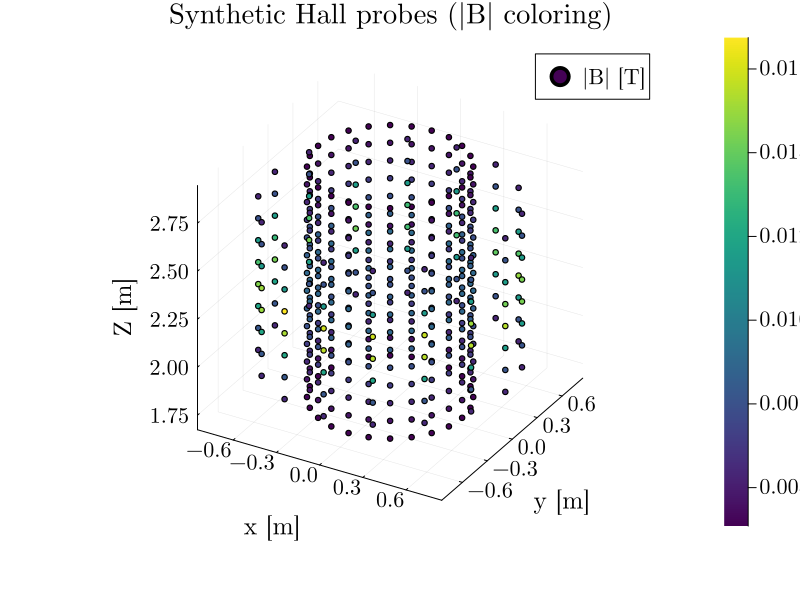

In [39]:
Bmag = sqrt.(out.B_R.^2 .+ out.B_phi.^2 .+ out.B_Z.^2)
x = out.R .* cos.(out.phi)
y = out.R .* sin.(out.phi)
scatter3d(x, y, out.Z;
    marker_z=Bmag, color=:viridis, markersize=3, label="|B| [T]",
    xlabel="x [m]", ylabel="y [m]", zlabel="Z [m]",
    title="Synthetic Hall probes (|B| coloring)",
    size=(800, 600), left_margin=8Plots.mm, bottom_margin=4Plots.mm)

## Fit a Hall file back to a coil pose (pose-blind)

The fitter consumes only `(R, φ, Z, B_R, B_φ, B_Z)` — no pose info — and recovers the rigid coil pose by iterative forward-modelling.

The residual uses **only B_R and B_Z**; B_φ is excluded because for near-axisymmetric coils like SPARC PF1U it is two orders of magnitude smaller than the in-plane components, so noise on B_φ would dominate that channel.

Two seeds are tracked separately:
- `noise_seed_input` — used to noise the input Hall file
- `noise_seed_fit`   — passed to the fitter (unused by the deterministic forward model, but recorded so callers can confirm the fit and the input do **not** share a noise realisation; the recovered pose can therefore never match the truth exactly)

In [40]:
include("fit_hall_cyl.jl")

# Two independent seeds.
noise_seed_input = 42
noise_seed_fit   = 137
@assert noise_seed_input != noise_seed_fit "seeds must differ"

# Regenerate input Hall file with a fixed 0.1 G floor + 0.1 % rel noise and
# the example pose from cell 2. The pose used here is the "truth" the
# fitter will try to recover.
input_path = joinpath(@__DIR__, "csvs", "synth_hall_for_fit.csv")
truth = synth_hall_cyl_to_file(
    input_path, coil_file,
    pose.dx, pose.dy, pose.dz;
    tx_deg=pose.tx_deg, ty_deg=pose.ty_deg, tz_deg=pose.tz_deg,
    current_A=current_A,
    R_probes=R_probes, phi_probes=phi_probes, Z_probes=Z_probes,
    noise_floor_T=1.0e-5,        # 0.1 G floor
    noise_rel_frac=1.0e-3,       # 0.1 %
    #noise_rel_frac=1.0e-1,       # 10 %
    noise_seed=noise_seed_input,
)

# Reload pose-blind: only grid + field, no pose info.
hall_blind = load_hall_cyl_csv(input_path)
println("hall_blind probes : ", length(hall_blind.R))
println("hall_blind fields : (R, phi, Z, B_R, B_phi, B_Z) -- no pose info available")

  Activating project at `~/Documents/GitHub/JULIA_GPEC`


Wrote /Users/bursche/Documents/GitHub/JULIA_GPEC/Coil_Axis_Example/csvs/synth_hall_for_fit.csv  (464 probes)
hall_blind probes : 464
hall_blind fields : (R, phi, Z, B_R, B_phi, B_Z) -- no pose info available


In [41]:
result = fit_pose_BR_BZ(
    coil_file, hall_blind;
    current_A=current_A,
    step0_m=0.050, step0_deg=0.5,
    tol_m=1e-7, tol_deg=1e-5,
    max_iter=200,
    fwd_noise_seed=noise_seed_fit,   # see note above; unused by the deterministic FM
    verbose=true,
)

println("\nseeds: input=$(noise_seed_input), fit=$(noise_seed_fit)")
println("\ntruth     vs recovered:")
@printf("  dx     %+10.4f mm   vs %+10.4f mm   (err %+8.4f mm)\n",
        pose.dx*1e3, result.pose[1]*1e3, (result.pose[1] - pose.dx)*1e3)
@printf("  dy     %+10.4f mm   vs %+10.4f mm   (err %+8.4f mm)\n",
        pose.dy*1e3, result.pose[2]*1e3, (result.pose[2] - pose.dy)*1e3)
@printf("  dz     %+10.4f mm   vs %+10.4f mm   (err %+8.4f mm)\n",
        pose.dz*1e3, result.pose[3]*1e3, (result.pose[3] - pose.dz)*1e3)
@printf("  tilt_x %+10.5f deg  vs %+10.5f deg  (err %+8.5f deg)\n",
        pose.tx_deg, result.pose[4], result.pose[4] - pose.tx_deg)
@printf("  tilt_y %+10.5f deg  vs %+10.5f deg  (err %+8.5f deg)\n",
        pose.ty_deg, result.pose[5], result.pose[5] - pose.ty_deg)
@printf("\nfinal residual: %.4e T^2  (n_eval=%d, n_iter=%d, converged=%s)\n",
        result.residual, result.n_eval, result.n_iter, result.converged)


fit_pose_BR_BZ result:
  iter=62, eval=621, converged=true, residual=1.486858e-07 T²
  pose: x=0.005008 m, y=-0.001994 m, z=0.001032 m, tx=0.299978 deg, ty=-0.101807 deg

seeds: input=42, fit=137

truth     vs recovered:
  dx        +5.0000 mm   vs    +5.0077 mm   (err  +0.0077 mm)
  dy        -2.0000 mm   vs    -1.9939 mm   (err  +0.0061 mm)
  dz        +1.0000 mm   vs    +1.0323 mm   (err  +0.0323 mm)
  tilt_x   +0.30000 deg  vs   +0.29998 deg  (err -0.00002 deg)
  tilt_y   -0.10000 deg  vs   -0.10181 deg  (err -0.00181 deg)

final residual: 1.4869e-07 T^2  (n_eval=621, n_iter=62, converged=true)


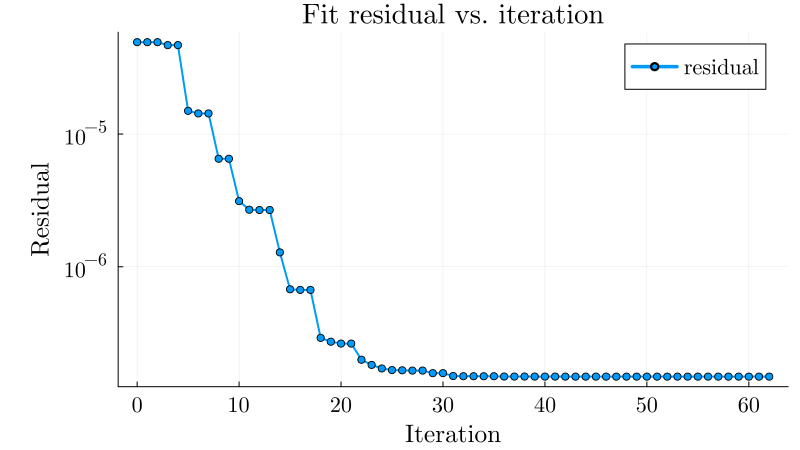

In [42]:

iters     = [h.iter     for h in result.history]
residuals = [h.residual for h in result.history]
Nprobes   = length(hall_blind.R)
# Expected asymptotic residual floor for the deterministic forward model:
# E[Σ_i (B_meas - B_true)²] over B_R + B_Z channels = 2 N σ², where σ is
# the per-component noise std at the median |B|.
Bmag_med  = median(sqrt.(hall_blind.B_R.^2 .+ hall_blind.B_phi.^2 .+ hall_blind.B_Z.^2))
σ_floor   = 1.0e-5
σ_rel     = 1.0e-3 * Bmag_med
σ_typ     = sqrt(σ_floor^2 + σ_rel^2)
residual_floor = 2 * Nprobes * σ_typ^2

p_res = plot(iters, residuals;
    yaxis=:log10, marker=:circle, lw=2, label="residual",
    xlabel="Iteration", ylabel="Residual", #Σ (ΔB_R² + ΔB_Z²)  [T²]",
    title="Fit residual vs. iteration",
    size=(800, 450), left_margin=10Plots.mm, bottom_margin=4Plots.mm)
#hline!(p_res, [residual_floor]; ls=:dash, color=:gray,
       #label="expected noise floor ≈ 2Nσ²")
savefig(p_res, joinpath(@__DIR__, "plots", "fit_residual_vs_iter.png"))
p_res

Diagnostic plots written to plots/:
  fit_residual_vs_iter.png
  fit_pose_trajectories.png
  fit_residual_histogram.png
  fit_bphi_sanity.png


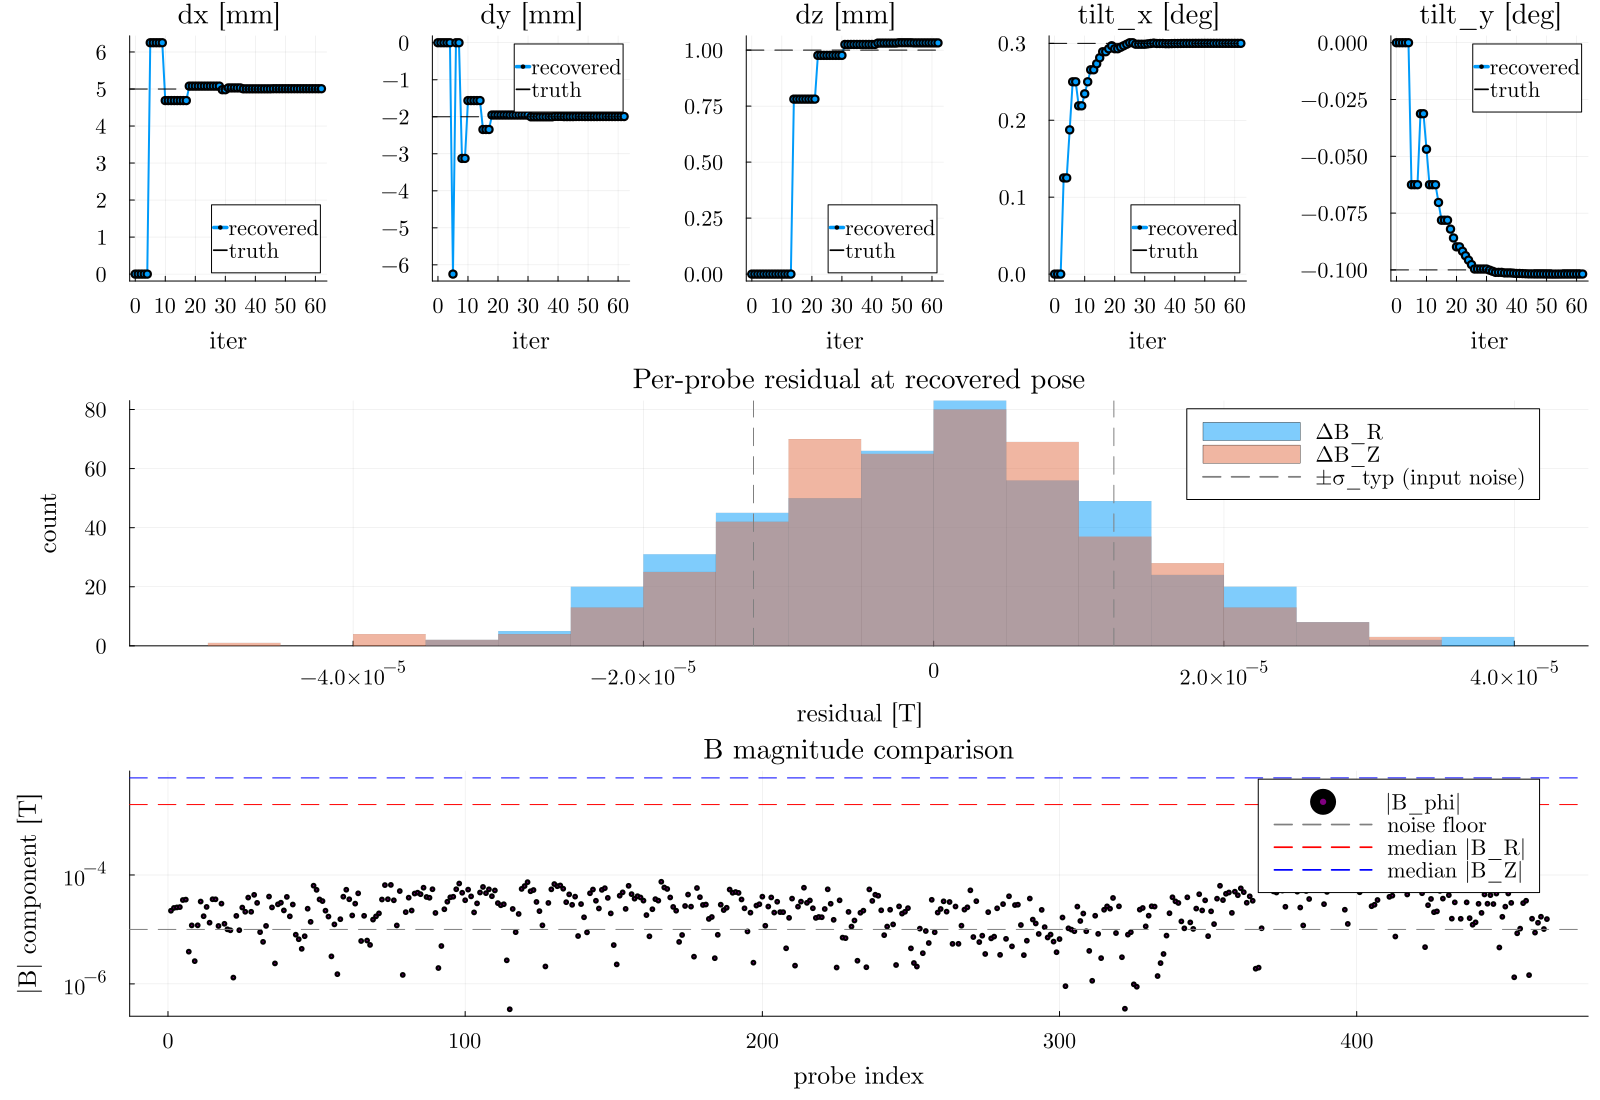

In [45]:
# Additional diagnostics

# (1) Pose-component trajectories — one panel per DOF
poses_hist = hcat([h.pose for h in result.history]...)   # 5 x niter+1
truth_vec  = [pose.dx, pose.dy, pose.dz, pose.tx_deg, pose.ty_deg]
labels     = ["dx [mm]", "dy [mm]", "dz [mm]", "tilt_x [deg]", "tilt_y [deg]"]
scales     = [1e3, 1e3, 1e3, 1.0, 1.0]
p_traj = plot(layout=(1, 5), size=(1600, 360),
              left_margin=6Plots.mm, bottom_margin=6Plots.mm)
for k in 1:5
    plot!(p_traj[k], iters, poses_hist[k, :] .* scales[k];
          marker=:circle, lw=2, label="recovered")
    hline!(p_traj[k], [truth_vec[k] * scales[k]];
           ls=:dash, color=:black, label="truth")
    title!(p_traj[k], labels[k])
    xlabel!(p_traj[k], "iter")
end
savefig(p_traj, joinpath(@__DIR__, "plots", "fit_pose_trajectories.png"))

# (2) Per-probe residuals at the recovered pose — should be Gaussian σ ≈ σ_typ
cs_eval = read_coil_dat(coil_file); cs_eval.currents .= current_A
place_coil!([cs_eval], result.pose[1], result.pose[2], result.pose[3];
            tx_deg=result.pose[4], ty_deg=result.pose[5])
N    = length(hall_blind.R)
BRp  = zeros(N); BPp = zeros(N); BZp = zeros(N)
compute_biot_savart_boundary!(BRp, BPp, BZp, hall_blind.R, hall_blind.phi, hall_blind.Z, [cs_eval])
dBR  = BRp .- hall_blind.B_R
dBZ  = BZp .- hall_blind.B_Z
p_hist = histogram(dBR; bins=30, label="ΔB_R", alpha=0.5, lw=0,
    xlabel="residual [T]", ylabel="count",
    title="Per-probe residual at recovered pose")
histogram!(p_hist, dBZ; bins=30, label="ΔB_Z", alpha=0.5, lw=0)
vline!(p_hist, [-σ_typ, σ_typ]; ls=:dash, color=:gray,
       label="±σ_typ (input noise)")
savefig(p_hist, joinpath(@__DIR__, "plots", "fit_residual_histogram.png"))

# (3) B magnitude comparison — |B_phi| is small compared to |B_R| / |B_Z|
abs_BR_med  = median(abs.(hall_blind.B_R))
abs_BP_med  = median(abs.(hall_blind.B_phi))
abs_BZ_med  = median(abs.(hall_blind.B_Z))
p_bphi = scatter(1:N, abs.(hall_blind.B_phi);
    markersize=2, label="|B_phi|", color=:purple,
    xlabel="probe index", ylabel="|B| component [T]",
    yaxis=:log10,
    title="B magnitude comparison",
    size=(800, 400), left_margin=10Plots.mm, bottom_margin=4Plots.mm)
    σ_floor
hline!(p_bphi, [σ_floor]; ls=:dash, color=:gray, label="noise floor")
hline!(p_bphi, [abs_BR_med]; ls=:dash, color=:red,   label="median |B_R|")
hline!(p_bphi, [abs_BZ_med]; ls=:dash, color=:blue,  label="median |B_Z|")

println("Diagnostic plots written to plots/:")
println("  fit_residual_vs_iter.png")
println("  fit_pose_trajectories.png")
println("  fit_residual_histogram.png")
println("  fit_bphi_sanity.png")
savefig(p_bphi, joinpath(@__DIR__, "plots", "fit_bphi_sanity.png"))
plot(p_traj, p_hist, p_bphi; layout=(3, 1), size=(1600, 1100),
     left_margin=10Plots.mm, bottom_margin=6Plots.mm)

## Noise → error mapping

Sweep the relative measurement noise over several orders of magnitude (the absolute floor stays at 1e-5 T = 0.1 G), re-noise the input file at each level with an **independent seed per level**, refit pose-blind, and plot the recovered shift / tilt error vs. input noise. For Gaussian measurement noise the recovered-pose error from a least-squares fit should scale linearly with σ — the dashed reference line on each subplot is the expected linear-in-σ slope, anchored to the lowest-noise data point.

noise sweep (floor=1.0e-5 T held fixed):
Wrote /Users/bursche/Documents/GitHub/JULIA_GPEC/Coil_Axis_Example/csvs/synth_hall_noise_scan.csv  (464 probes)
  rel=1e-04  | shift_err=0.0158 mm  tilt_err=0.00144 deg  residual=9.913e-08 T^2
Wrote /Users/bursche/Documents/GitHub/JULIA_GPEC/Coil_Axis_Example/csvs/synth_hall_noise_scan.csv  (464 probes)
  rel=1e-03  | shift_err=0.0382 mm  tilt_err=0.00143 deg  residual=1.512e-07 T^2
Wrote /Users/bursche/Documents/GitHub/JULIA_GPEC/Coil_Axis_Example/csvs/synth_hall_noise_scan.csv  (464 probes)
  rel=1e-02  | shift_err=0.1089 mm  tilt_err=0.01151 deg  residual=6.434e-06 T^2
Wrote /Users/bursche/Documents/GitHub/JULIA_GPEC/Coil_Axis_Example/csvs/synth_hall_noise_scan.csv  (464 probes)
  rel=5e-02  | shift_err=0.5936 mm  tilt_err=0.05591 deg  residual=1.476e-04 T^2
Wrote /Users/bursche/Documents/GitHub/JULIA_GPEC/Coil_Axis_Example/csvs/synth_hall_noise_scan.csv  (464 probes)
  rel=1e-01  | shift_err=0.9986 mm  tilt_err=0.10648 deg  residual=5.967e-0

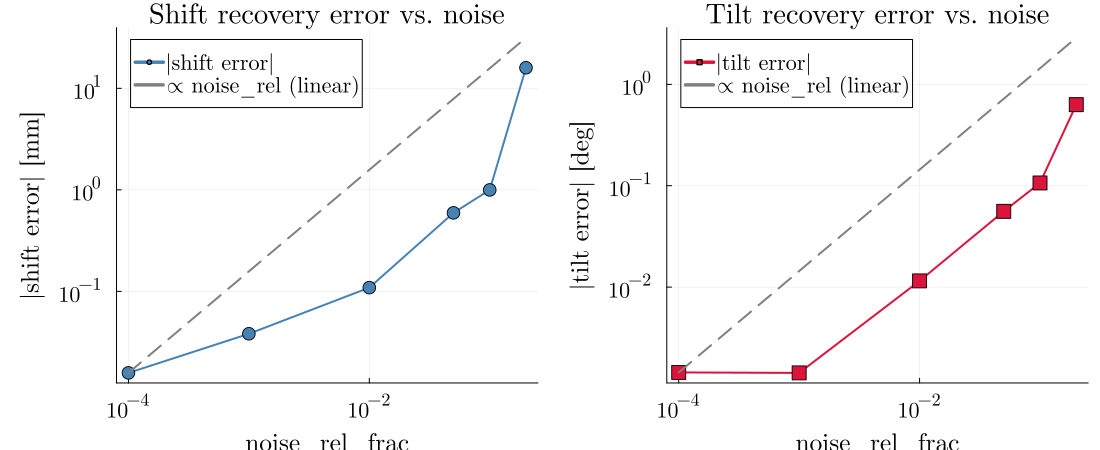

In [46]:
noise_rel_levels = [1.0e-4, 1.0e-3, 1.0e-2, 5.0e-2, 1.0e-1, 2.0e-1]
noise_floor_T    = 1.0e-5    # held fixed
scan_csv_path    = joinpath(@__DIR__, "csvs", "synth_hall_noise_scan.csv")

truth_xyz   = [pose.dx, pose.dy, pose.dz]
truth_tilts = [pose.tx_deg, pose.ty_deg]

shift_errs_mm = Float64[]
tilt_errs_deg = Float64[]
residuals_T2  = Float64[]

println("noise sweep (floor=$(noise_floor_T) T held fixed):")
for (i, rel) in enumerate(noise_rel_levels)
    # Independent noise realisation per level.
    seed_k = noise_seed_input + i * 1000
    synth_hall_cyl_to_file(
        scan_csv_path, coil_file,
        pose.dx, pose.dy, pose.dz;
        tx_deg=pose.tx_deg, ty_deg=pose.ty_deg, tz_deg=pose.tz_deg,
        current_A=current_A,
        R_probes=R_probes, phi_probes=phi_probes, Z_probes=Z_probes,
        noise_floor_T=noise_floor_T,
        noise_rel_frac=rel,
        noise_seed=seed_k,
    )
    hall_k = load_hall_cyl_csv(scan_csv_path)
    result_k = fit_pose_BR_BZ(
        coil_file, hall_k;
        current_A=current_A,
        step0_m=0.050, step0_deg=0.5,
        tol_m=1e-7, tol_deg=1e-5,
        max_iter=200,
        fwd_noise_seed=noise_seed_fit,
        verbose=false,
    )
    se = sqrt(sum((result_k.pose[1:3] .- truth_xyz).^2)) * 1e3   # mm
    te = sqrt(sum((result_k.pose[4:5] .- truth_tilts).^2))       # deg
    push!(shift_errs_mm, se)
    push!(tilt_errs_deg, te)
    push!(residuals_T2,  result_k.residual)
    @printf("  rel=%.0e  | shift_err=%.4f mm  tilt_err=%.5f deg  residual=%.3e T^2\n",
            rel, se, te, result_k.residual)
end

# Linear-in-σ reference line, anchored to the lowest-noise data point.
ref_shift = shift_errs_mm[1] .* (noise_rel_levels ./ noise_rel_levels[1])
ref_tilt  = tilt_errs_deg[1] .* (noise_rel_levels ./ noise_rel_levels[1])

p_noise = plot(layout=(1, 2), size=(1100, 450),
               left_margin=10Plots.mm, bottom_margin=6Plots.mm)
plot!(p_noise[1], noise_rel_levels, shift_errs_mm;
      xaxis=:log10, yaxis=:log10, marker=:circle, lw=2, ms=7,
      color=:steelblue, label="|shift error|")
plot!(p_noise[1], noise_rel_levels, ref_shift;
      ls=:dash, color=:gray, lw=2, label="∝ noise_rel (linear)")
xlabel!(p_noise[1], "noise_rel_frac")
ylabel!(p_noise[1], "|shift error| [mm]")
title!(p_noise[1], "Shift recovery error vs. noise")

plot!(p_noise[2], noise_rel_levels, tilt_errs_deg;
      xaxis=:log10, yaxis=:log10, marker=:square, lw=2, ms=7,
      color=:crimson, label="|tilt error|")
plot!(p_noise[2], noise_rel_levels, ref_tilt;
      ls=:dash, color=:gray, lw=2, label="∝ noise_rel (linear)")
xlabel!(p_noise[2], "noise_rel_frac")
ylabel!(p_noise[2], "|tilt error| [deg]")
title!(p_noise[2], "Tilt recovery error vs. noise")

savefig(p_noise, joinpath(@__DIR__, "plots", "noise_to_error.png"))
println("\nWrote plots/noise_to_error.png")
p_noise

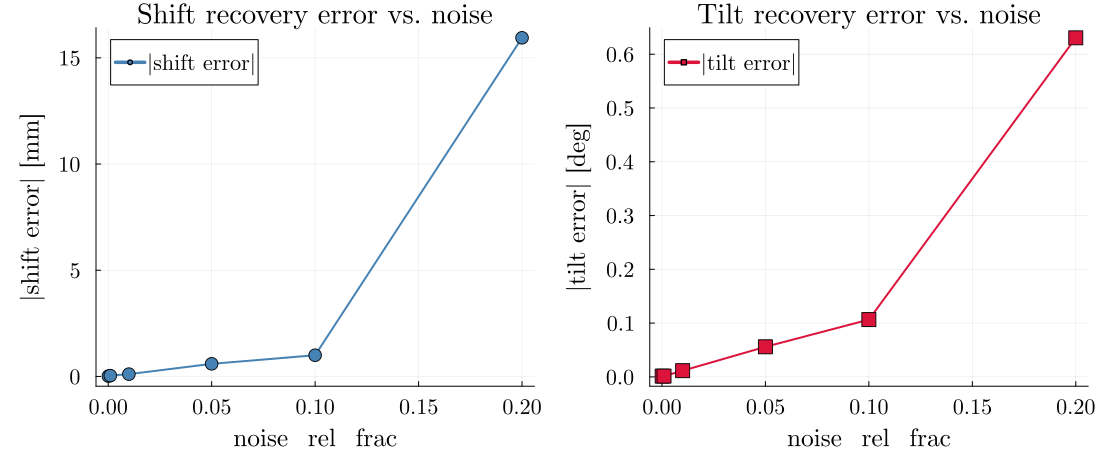

In [52]:
# Linear-in-σ reference line, anchored to the lowest-noise data point.
ref_shift = shift_errs_mm[1] .* (noise_rel_levels ./ noise_rel_levels[1])
ref_tilt  = tilt_errs_deg[1] .* (noise_rel_levels ./ noise_rel_levels[1])

p_noise = plot(layout=(1, 2), size=(1100, 450),
               left_margin=10Plots.mm, bottom_margin=6Plots.mm)
plot!(p_noise[1], noise_rel_levels, shift_errs_mm;
      marker=:circle, lw=2, ms=7,
      color=:steelblue, label="|shift error|")
#plot!(p_noise[1], noise_rel_levels, ref_shift;
#      ls=:dash, color=:gray, lw=2, label="∝ noise_rel (linear)")
xlabel!(p_noise[1], "noise_rel_frac")
ylabel!(p_noise[1], "|shift error| [mm]")
title!(p_noise[1], "Shift recovery error vs. noise")

plot!(p_noise[2], noise_rel_levels, tilt_errs_deg;
      marker=:square, lw=2, ms=7,
      color=:crimson, label="|tilt error|")
#plot!(p_noise[2], noise_rel_levels, ref_tilt;
#      ls=:dash, color=:gray, lw=2, label="∝ noise_rel (linear)")
xlabel!(p_noise[2], "noise_rel_frac")
ylabel!(p_noise[2], "|tilt error| [deg]")
title!(p_noise[2], "Tilt recovery error vs. noise")

#savefig(p_noise, joinpath(@__DIR__, "plots", "noise_to_error.png"))
#println("\nWrote plots/noise_to_error.png")
#p_noise